C:\Users\bimat\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\bimat\AppData\Local\Temp\ipykernel_13756\695474259.py:60: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|████████████████████████████████████████████████████████████████████████████████| 849k/849k [00:01<00:00, 567kB/s]


BASIC SHAPE
Rows    : 10,000
Columns : 13

COLUMN TYPES
Vehicle_ID                     str
Car_Model                      str
Battery_Type                   str
Battery_Capacity_kWh       float64
Vehicle_Age_Months           int64
Total_Charging_Cycles        int64
Avg_Temperature_C          float64
Fast_Charge_Ratio          float64
Avg_Discharge_Rate_C       float64
Driving_Style                  str
Internal_Resistance_Ohm    float64
SoH_Percent                float64
Battery_Status                 str
dtype: object

MISSING VALUES
                         missing_count  missing_%
Vehicle_ID                           0        0.0
Car_Model                            0        0.0
Battery_Type                         0        0.0
Battery_Capacity_kWh                 0        0.0
Vehicle_Age_Months                   0        0.0
Total_Charging_Cycles                0        0.0
Avg_Temperature_C                    0        0.0
Fast_Charge_Ratio                    0        0.0
Avg_Disch

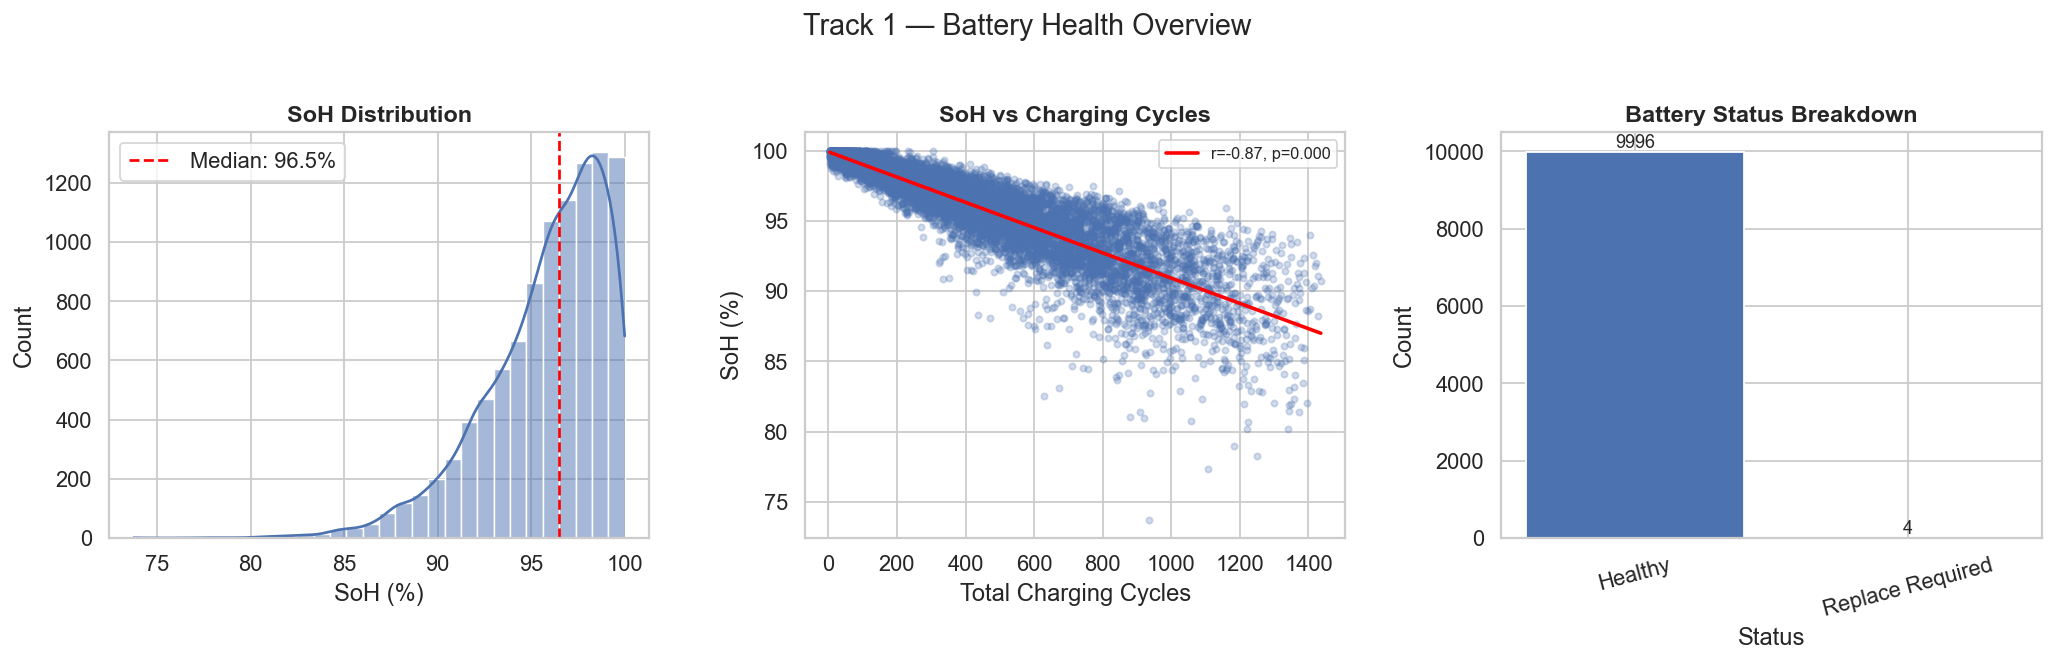


[Track 1] Saved → track1_core_story.png


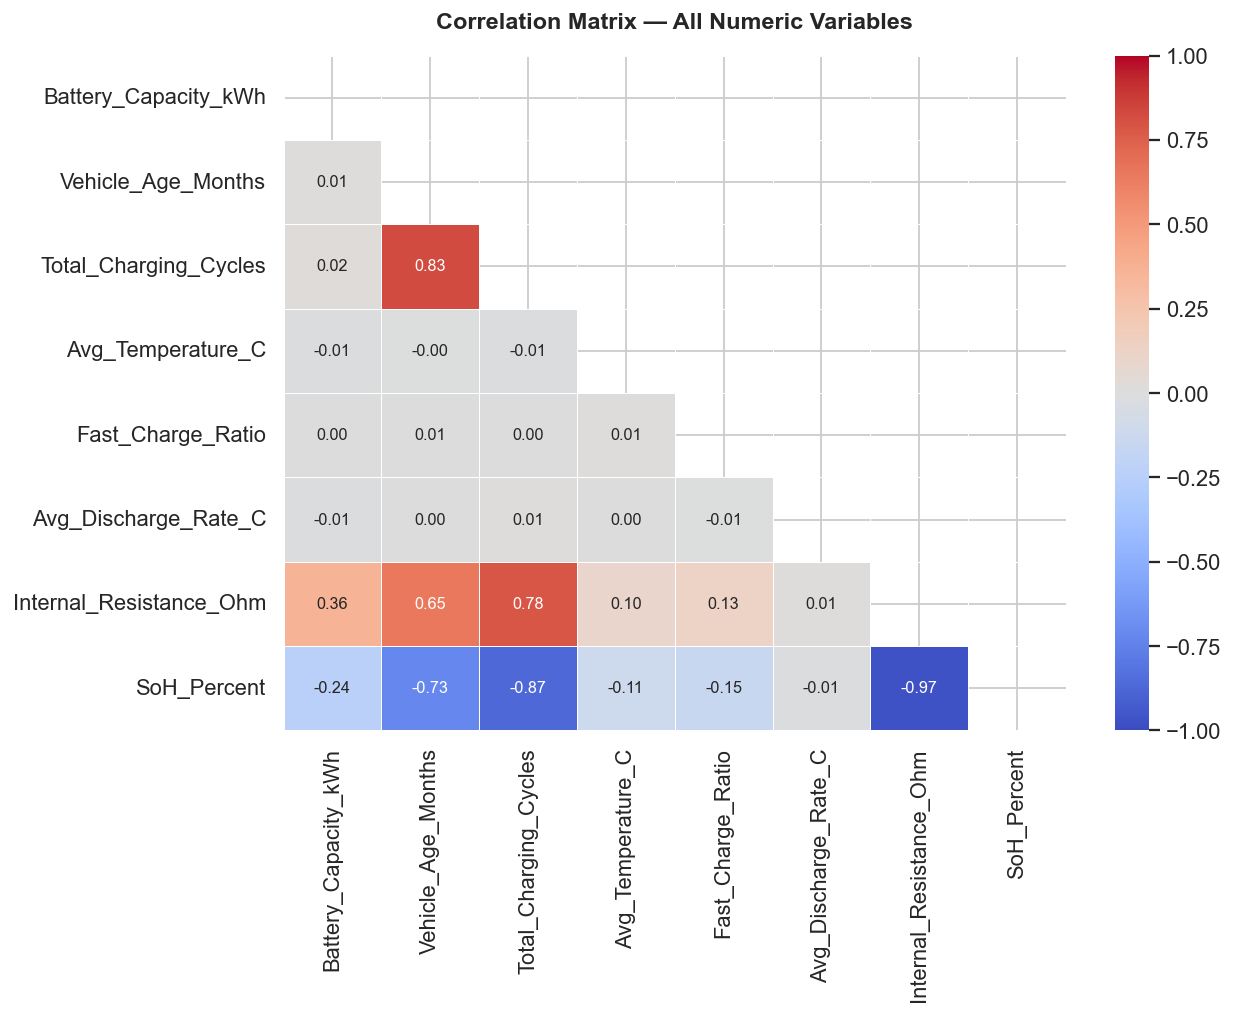


Correlations with SoH_Percent (sorted):
Internal_Resistance_Ohm   -0.971986
Total_Charging_Cycles     -0.873213
Vehicle_Age_Months        -0.726202
Battery_Capacity_kWh      -0.238259
Fast_Charge_Ratio         -0.150041
Avg_Temperature_C         -0.112250
Avg_Discharge_Rate_C      -0.014735
Name: SoH_Percent, dtype: float64


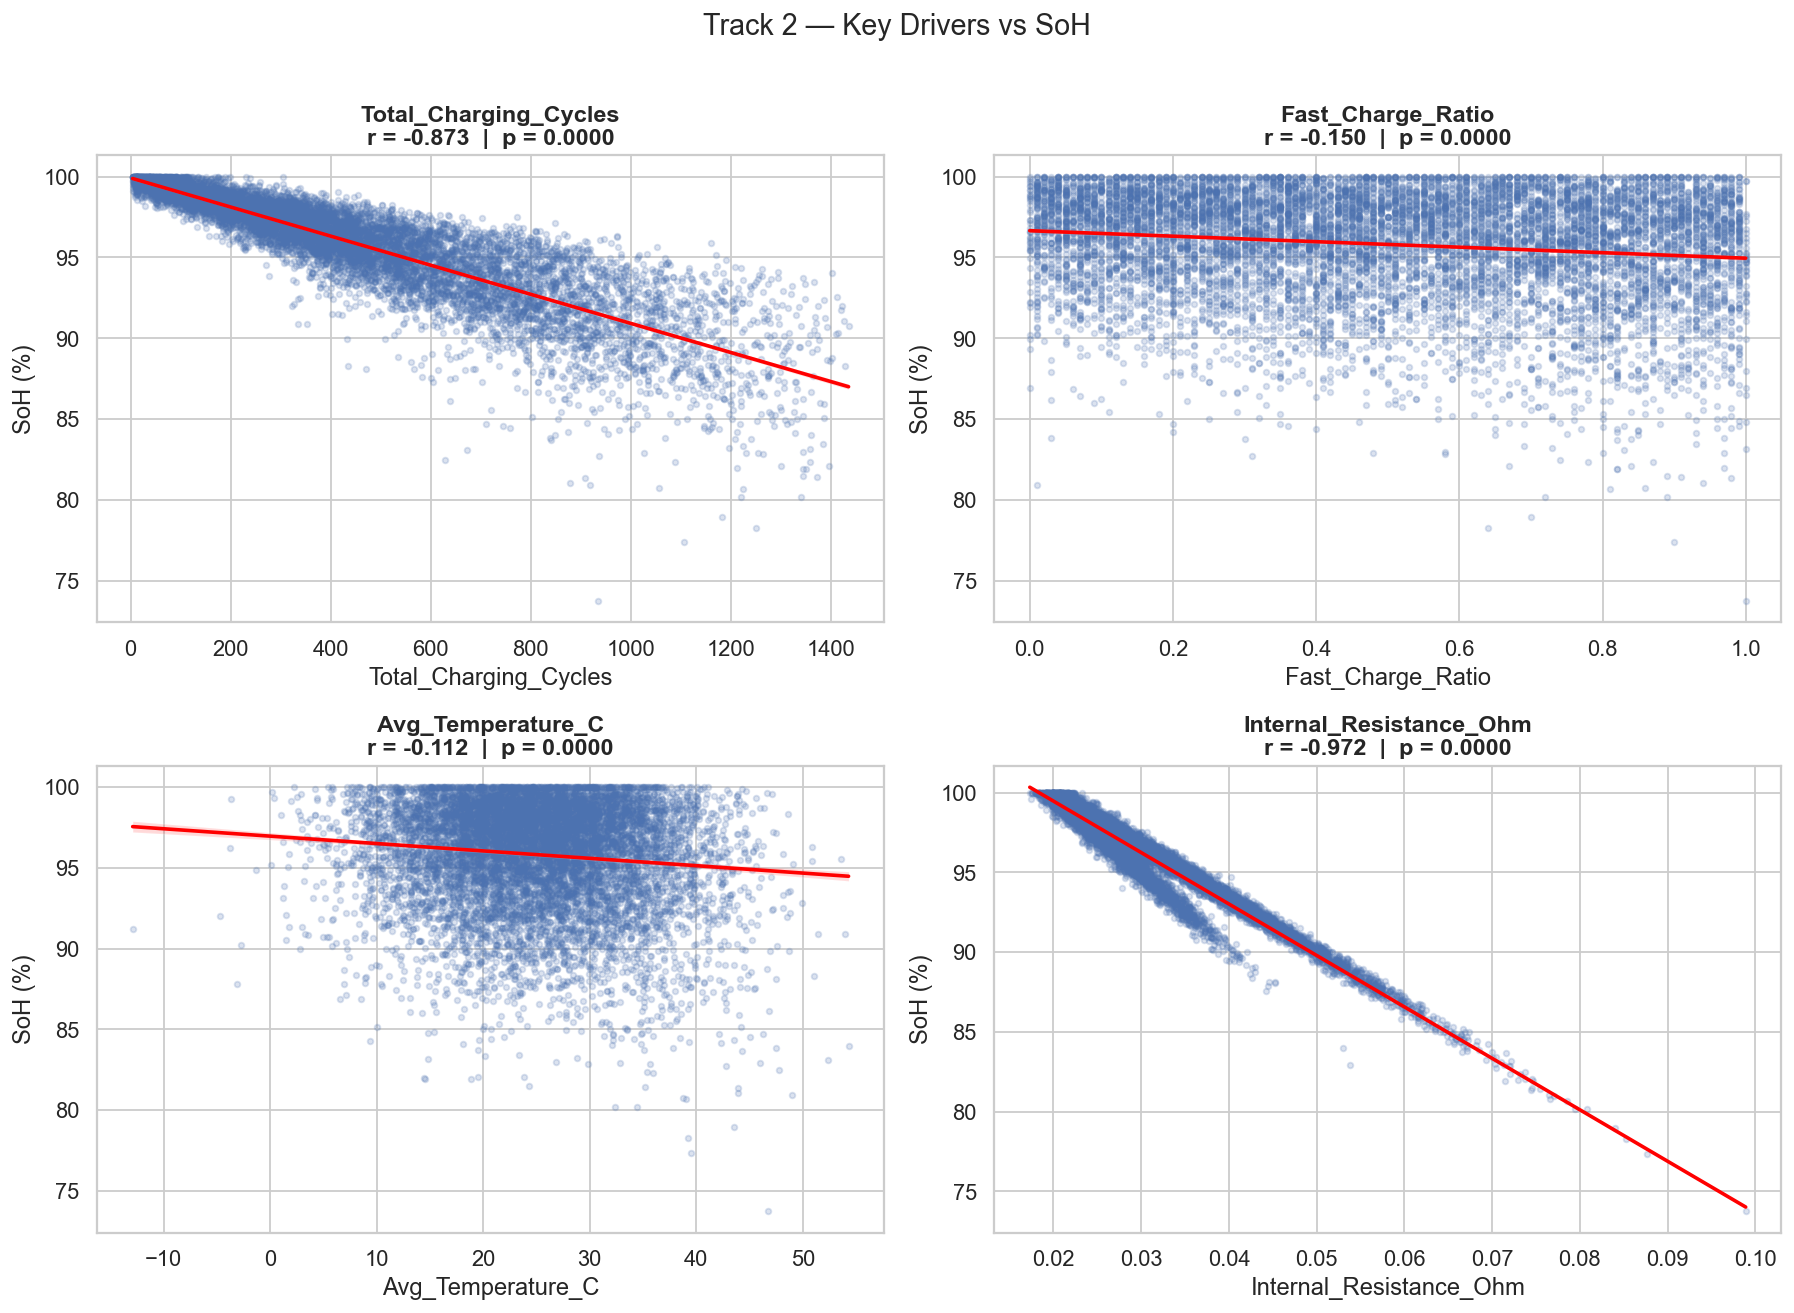


[Track 2] Saved → track2_driver_scatters.png


C:\Users\bimat\AppData\Local\Temp\ipykernel_13756\695474259.py:316: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


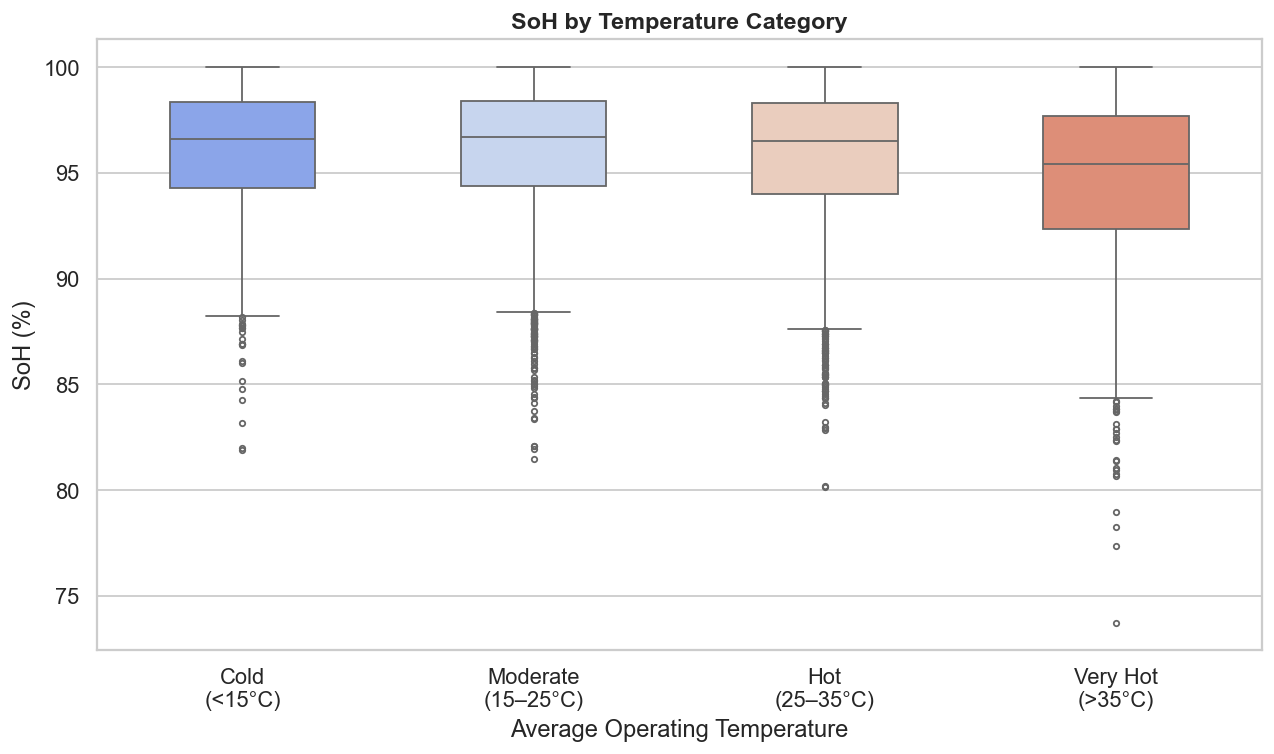

C:\Users\bimat\AppData\Local\Temp\ipykernel_13756\695474259.py:346: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


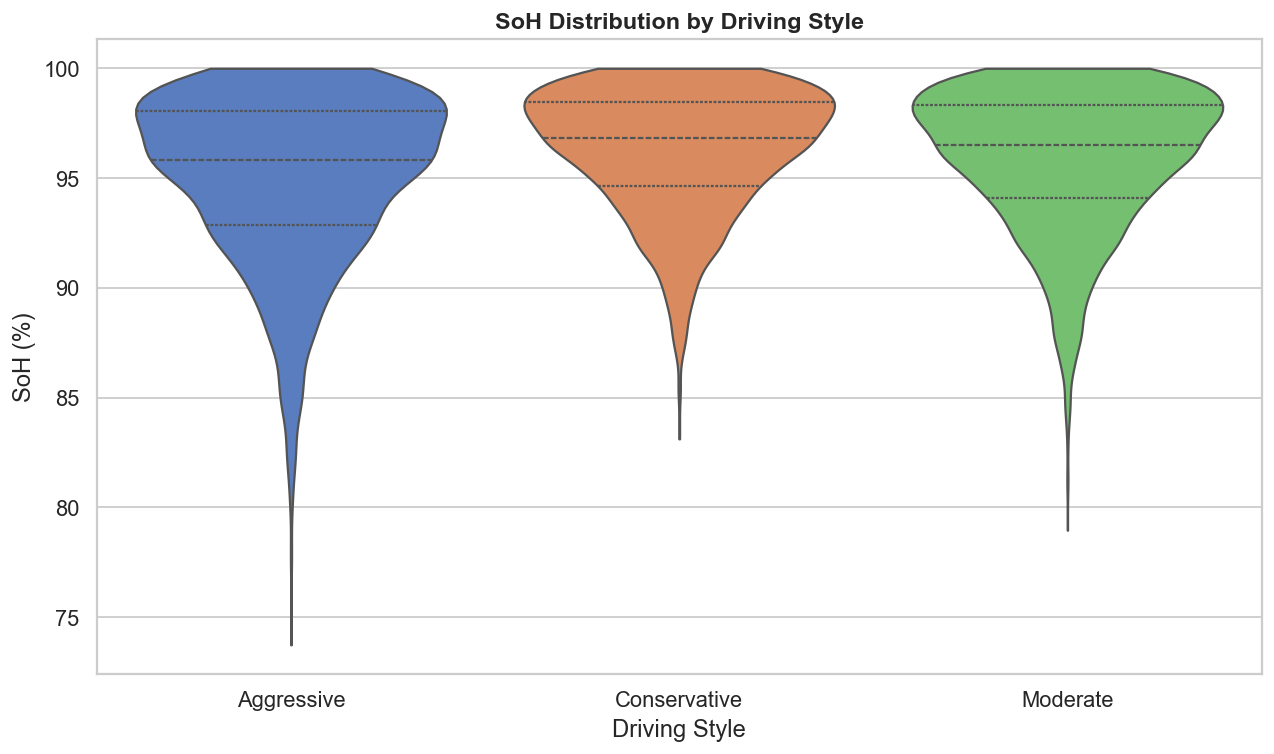


[Track 2] All driver plots saved.


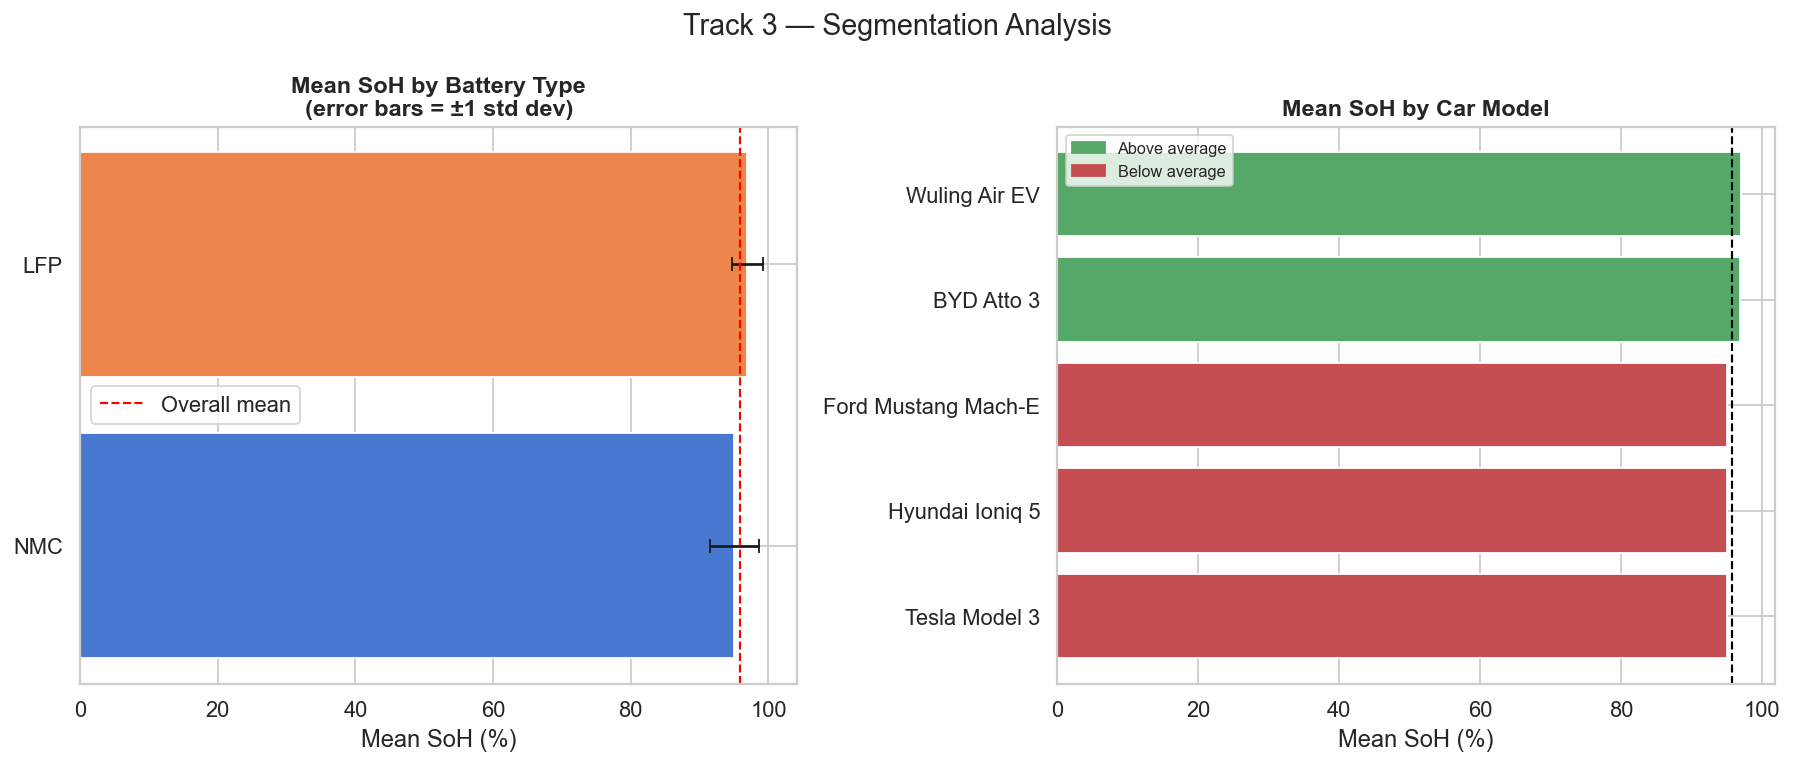

C:\Users\bimat\AppData\Local\Temp\ipykernel_13756\695474259.py:441: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Age_Group", y="SoH_Percent",


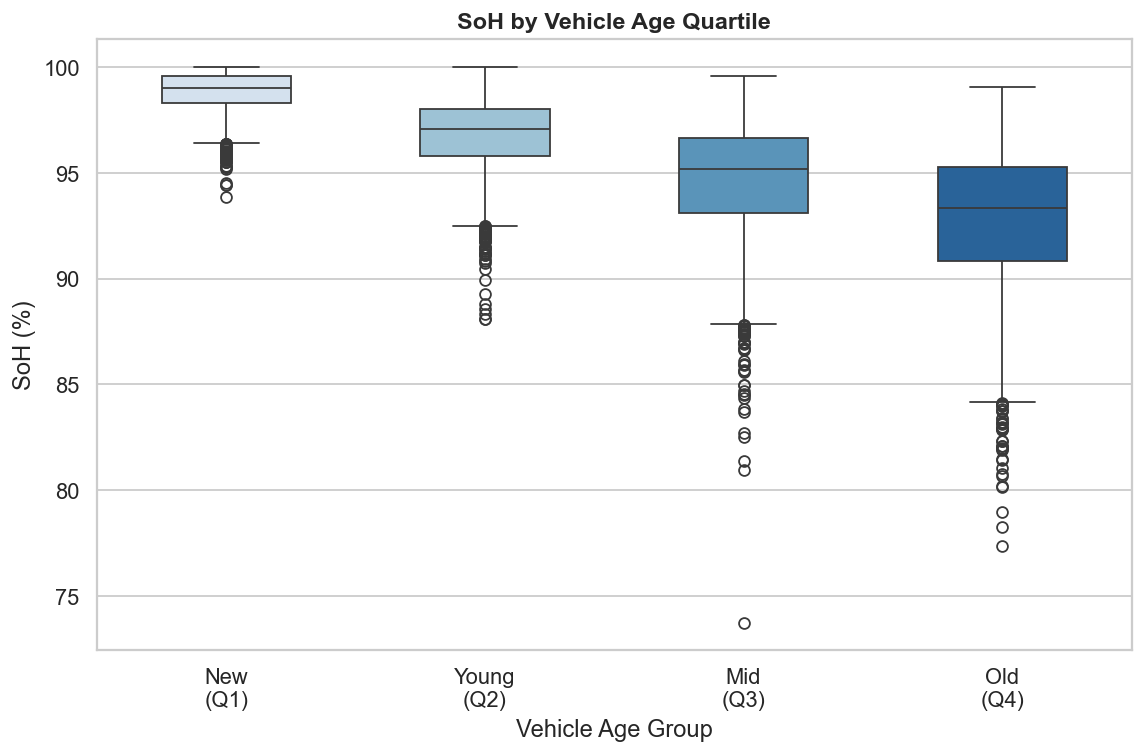


[Track 3] Segmentation plots saved.

Outlier threshold: residual < -3.17
Flagged vehicles : 308 / 10000 (3.1%)


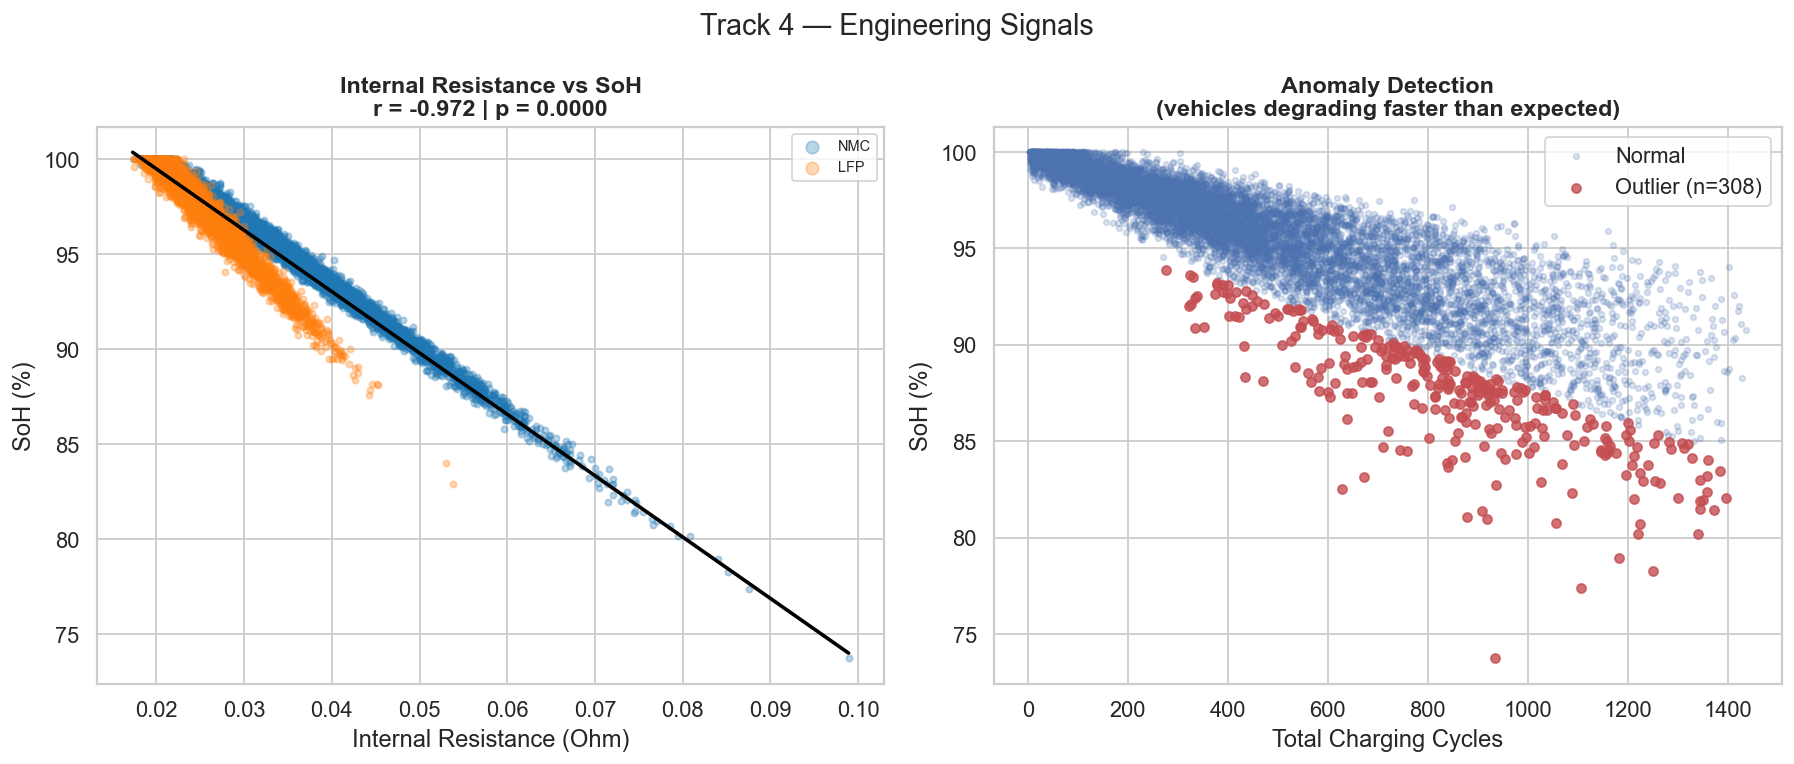

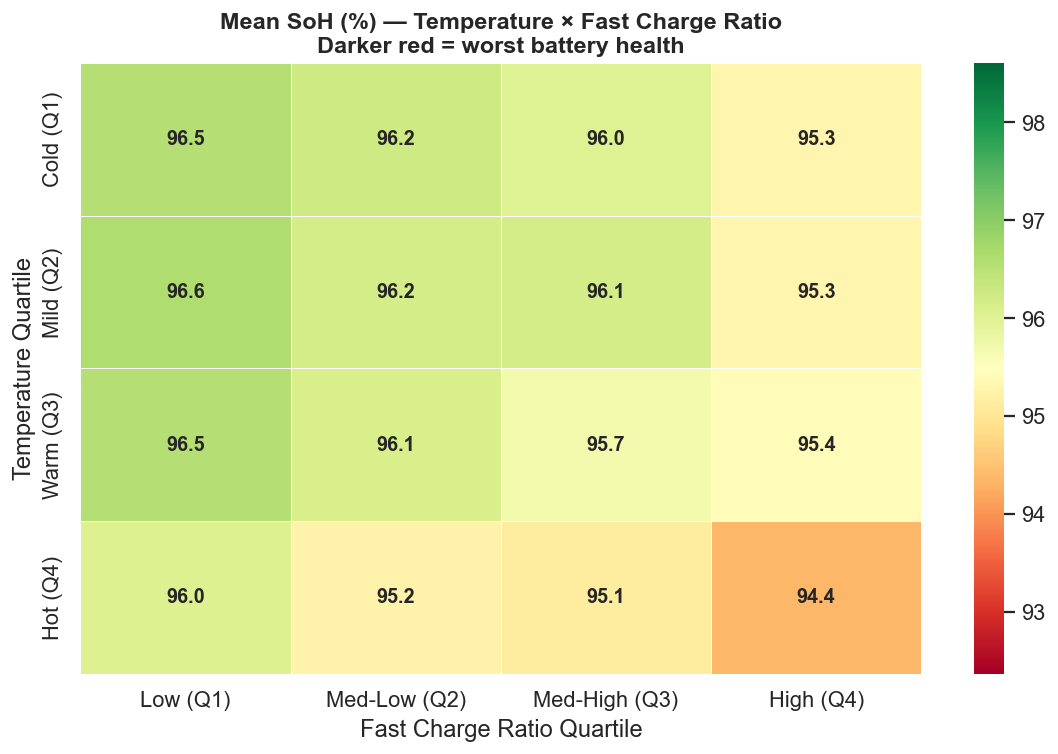


[Track 4] Engineering signal plots saved.

KEY FINDINGS SUMMARY
  Correlation: Cycles → SoH                  r = -0.873  (↓ hurts SoH)
  Correlation: Fast Charge → SoH             r = -0.150  (↓ hurts SoH)
  Correlation: Temperature → SoH             r = -0.112  (↓ hurts SoH)
  Correlation: Int. Resistance → SoH         r = -0.972  (↓ hurts SoH)
  Correlation: Discharge Rate → SoH          r = -0.015  (↓ hurts SoH)

  Anomalous vehicles flagged : 308 (3.1%)

All charts saved as PNG files in the current directory.
Recommended Jupyter structure:
  1. track1_core_story.png
  2. track2_correlation_heatmap.png
  3. track2_driver_scatters.png
  4. track2_temp_boxplot.png
  5. track2_driving_style_violin.png
  6. track3_segmentation.png
  7. track3_age_soh.png
  8. track4_engineering_signal.png
  9. track4_worst_combination.png  ← your strongest slide


In [1]:
# ============================================================
#  EV Battery Degradation — Full EDA Portfolio Script
#  Author: Bimatmaja Nityasa Pambudi Kartika Putra | Dataset: Kaggle Electric Vehicle (EV) Battery Degradation & Charge
# ============================================================
#
#  HOW TO USE THIS FILE
#  ---------------------
#  Run this in a Jupyter Notebook (.ipynb) for best results.
#  Each section is self-contained — you can run them in order
#  or jump to any section independently.
#
#  Required libraries (install once):
#    pip install pandas matplotlib seaborn scipy kagglehub


# ─────────────────────────────────────────────
#  SECTION 0 — Imports & Setup
# ─────────────────────────────────────────────
#
#  WHY: We import our tools first. Think of this like
#  gathering all your equipment before starting a project.
#
#  pandas  → handles tabular data (like Excel, but in Python)
#  numpy   → math operations on arrays
#  matplotlib → base plotting library
#  seaborn → prettier statistical plots built on matplotlib
#  scipy   → for statistical tests (correlation significance)
#  kagglehub → for importing dataset directly from kaggle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import kagglehub
from kagglehub import KaggleDatasetAdapter

# --- Global plot style ---
# These two lines make ALL plots look consistent and clean.
# "whitegrid" adds light gray gridlines so values are easier to read.
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 130          # higher = sharper images
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13


# ─────────────────────────────────────────────
#  SECTION 1 — Load & Inspect Data
# ─────────────────────────────────────────────
#
#  WHY: Before ANY analysis, you must understand the shape
#  and quality of your data. This is called "sanity checking."
#  Skipping this step leads to wrong conclusions later.

# Set the path to the file you'd like to load
file_path = "ev_battery_degradation_v1.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "bertnardomariouskono/electric-vehicle-ev-battery-degradation-and-charge",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
) 

df.head() # check if the file is correct

print("=" * 55)
print("BASIC SHAPE")
print("=" * 55)
print(f"Rows    : {df.shape[0]:,}")   # how many vehicles/records
print(f"Columns : {df.shape[1]}")

print("\n" + "=" * 55)
print("COLUMN TYPES")
print("=" * 55)
# dtypes tells you which columns are numeric (int64/float64)
# and which are text (object). Important for choosing chart types.
print(df.dtypes)

print("\n" + "=" * 55)
print("MISSING VALUES")
print("=" * 55)
# isnull().sum() counts NaN (empty) cells per column.
# Missing data affects every analysis — always check first.
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({"missing_count": missing, "missing_%": missing_pct}))

print("\n" + "=" * 55)
print("DESCRIPTIVE STATISTICS (numeric columns)")
print("=" * 55)
# .describe() gives: count, mean, std, min, 25%, 50%, 75%, max
# This is your first view of the "spread" of each variable.
# Pay attention to min/max — extreme values can be data errors.
print(df.describe().round(2))

print("\n" + "=" * 55)
print("CATEGORICAL COLUMN COUNTS")
print("=" * 55)
cat_cols = ["Car_Model", "Battery_Type", "Driving_Style", "Battery_Status"]
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


# ─────────────────────────────────────────────
#  SECTION 2 — Track 1: Core Story (SoH)
# ─────────────────────────────────────────────
#
#  WHY: SoH_Percent is our main outcome variable.
#  Before diving into "what causes degradation", we first
#  show the reader what the degradation landscape looks like.
#  This is your opening argument.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Track 1 — Battery Health Overview", y=1.02)

# ── Plot 1: SoH Distribution ──
# A histogram shows the frequency of each SoH value.
# sns.histplot with kde=True overlays a smooth density curve —
# this helps you see the "shape" of the distribution:
# is it normal (bell curve)? skewed left/right?
sns.histplot(
    df["SoH_Percent"],
    bins=30,           # number of bars; more bins = more detail
    kde=True,          # Kernel Density Estimate = smooth curve on top
    color="#4C72B0",
    ax=axes[0]
)
axes[0].set_title("SoH Distribution")
axes[0].set_xlabel("SoH (%)")
axes[0].set_ylabel("Count")
# Add a vertical line at the median — gives instant visual reference
axes[0].axvline(df["SoH_Percent"].median(), color="red",
                linestyle="--", linewidth=1.5, label=f"Median: {df['SoH_Percent'].median():.1f}%")
axes[0].legend()

# ── Plot 2: SoH vs Total Charging Cycles (scatter) ──
# This is your "degradation curve" — the core narrative.
# As cycles increase, SoH should fall. If this relationship
# is clear, it validates the dataset and tells your story.
# alpha=0.3 makes points semi-transparent so overlapping
# points don't form a solid blob (overplotting).
axes[1].scatter(
    df["Total_Charging_Cycles"],
    df["SoH_Percent"],
    alpha=0.25,        # transparency: 0=invisible, 1=solid
    s=12,              # dot size
    color="#4C72B0"
)
# Add a linear regression line (line of best fit) to show the trend
m, b, r, p, _ = stats.linregress(df["Total_Charging_Cycles"], df["SoH_Percent"])
x_range = np.linspace(df["Total_Charging_Cycles"].min(),
                      df["Total_Charging_Cycles"].max(), 200)
axes[1].plot(x_range, m * x_range + b, color="red", linewidth=2,
             label=f"r={r:.2f}, p={p:.3f}")
# r = correlation coefficient (-1 to 1). Closer to -1 = strong negative trend.
# p = p-value. If p < 0.05, the trend is statistically significant.
axes[1].set_title("SoH vs Charging Cycles")
axes[1].set_xlabel("Total Charging Cycles")
axes[1].set_ylabel("SoH (%)")
axes[1].legend(fontsize=9)

# ── Plot 3: Battery Status Breakdown ──
# Battery_Status is a categorical label (e.g. Good / Degraded / Critical).
# A bar chart shows how many vehicles fall into each status.
# value_counts() counts occurrences of each unique category.
status_counts = df["Battery_Status"].value_counts()
colors_status = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
bars = axes[2].bar(status_counts.index, status_counts.values,
                   color=colors_status[:len(status_counts)], edgecolor="white")
# Add count labels on top of each bar for readability
for bar in bars:
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,  # x center of bar
        bar.get_height() + 5,               # just above the bar
        str(int(bar.get_height())),
        ha="center", va="bottom", fontsize=10
    )
axes[2].set_title("Battery Status Breakdown")
axes[2].set_xlabel("Status")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("track1_core_story.png", bbox_inches="tight")
plt.show()
print("\n[Track 1] Saved → track1_core_story.png")


# ─────────────────────────────────────────────
#  SECTION 3 — Track 2: Driver Analysis
# ─────────────────────────────────────────────
#
#  WHY: Now we ask "what variables most strongly predict SoH?"
#  This is the analytical heart of the EDA. We use:
#   - Correlation heatmap (overview of all relationships)
#   - Individual scatter plots (deep dive on top suspects)
#   - Boxplots (compare SoH across groups)

# ── 3A: Correlation Heatmap ──
#
# A correlation heatmap shows the Pearson correlation coefficient
# between every pair of numeric variables. Values range from:
#   +1.0 → perfect positive relationship (both go up together)
#    0.0 → no linear relationship
#   -1.0 → perfect negative relationship (one up = other down)
#
# For SoH, we EXPECT negative correlations with:
#   - Total_Charging_Cycles (more cycles → lower SoH)
#   - Fast_Charge_Ratio     (more fast charging → lower SoH)
#   - Internal_Resistance   (higher resistance = more degraded)

numeric_cols = [
    "Battery_Capacity_kWh", "Vehicle_Age_Months", "Total_Charging_Cycles",
    "Avg_Temperature_C", "Fast_Charge_Ratio", "Avg_Discharge_Rate_C",
    "Internal_Resistance_Ohm", "SoH_Percent"
]

corr_matrix = df[numeric_cols].corr()   # compute all pairwise correlations

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle (it's a mirror)
sns.heatmap(
    corr_matrix,
    mask=mask,            # show only lower triangle
    annot=True,           # print the number inside each cell
    fmt=".2f",            # 2 decimal places
    cmap="coolwarm",      # blue=negative, red=positive
    center=0,             # white = 0 (no correlation)
    vmin=-1, vmax=1,      # fix scale so colors are consistent
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 9}
)
ax.set_title("Correlation Matrix — All Numeric Variables", pad=15)
plt.tight_layout()
plt.savefig("track2_correlation_heatmap.png", bbox_inches="tight")
plt.show()

# Print sorted correlations with SoH (most insightful line of this section)
print("\nCorrelations with SoH_Percent (sorted):")
print(corr_matrix["SoH_Percent"].drop("SoH_Percent").sort_values())


# ── 3B: Top 4 Driver Scatter Plots ──
#
# For the 4 strongest correlates with SoH, we make individual
# scatter plots. This lets you see the relationship's shape:
#   - Is it linear? Or does it curve?
#   - Are there clusters? (suggests subcategories in the data)
#   - Are there outliers pulling the line?

top_drivers = [
    "Total_Charging_Cycles",
    "Fast_Charge_Ratio",
    "Avg_Temperature_C",
    "Internal_Resistance_Ohm"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Track 2 — Key Drivers vs SoH", y=1.01)
axes = axes.flatten()   # convert 2x2 grid → flat list for easy looping

for i, col in enumerate(top_drivers):
    # Scatter plot with jitter-free points
    axes[i].scatter(
        df[col], df["SoH_Percent"],
        alpha=0.2, s=10, color="#4C72B0"
    )
    # Regression line + confidence interval via seaborn regplot
    # ci=95 shades the 95% confidence band around the line
    sns.regplot(
        data=df, x=col, y="SoH_Percent",
        scatter=False,      # don't re-draw the dots
        ci=95,              # 95% confidence interval band
        line_kws={"color": "red", "linewidth": 2},
        ax=axes[i]
    )
    # Compute and display r and p-value in the corner
    r_val, p_val = stats.pearsonr(df[col], df["SoH_Percent"])
    axes[i].set_title(f"{col}\nr = {r_val:.3f}  |  p = {p_val:.4f}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("SoH (%)")

plt.tight_layout()
plt.savefig("track2_driver_scatters.png", bbox_inches="tight")
plt.show()
print("\n[Track 2] Saved → track2_driver_scatters.png")


# ── 3C: Temperature Bin Boxplot ──
#
# Instead of a raw scatter, we bin temperature into categories
# (Cold / Moderate / Hot / Very Hot) and draw a boxplot per bin.
#
# WHY BINS? A boxplot shows median, spread, and outliers clearly.
# It answers: "Does SoH drop as temperature rises, step by step?"
#
# pd.cut() divides a continuous variable into equal-width buckets.
# You define the edges and the labels.

temp_bins   = [0,  15,  25,  35,  60]
temp_labels = ["Cold\n(<15°C)", "Moderate\n(15–25°C)",
               "Hot\n(25–35°C)", "Very Hot\n(>35°C)"]

df["Temp_Bin"] = pd.cut(df["Avg_Temperature_C"],
                        bins=temp_bins, labels=temp_labels)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="Temp_Bin",
    y="SoH_Percent",
    palette="coolwarm",   # cool=blue for cold, warm=red for hot
    order=temp_labels,
    width=0.5,
    fliersize=3           # size of outlier dots
)
# A boxplot reads as:
#   - Line in middle  = median
#   - Box edges       = 25th and 75th percentile (IQR)
#   - Whiskers        = 1.5 × IQR from box edges
#   - Dots beyond     = outliers
ax.set_title("SoH by Temperature Category")
ax.set_xlabel("Average Operating Temperature")
ax.set_ylabel("SoH (%)")
plt.tight_layout()
plt.savefig("track2_temp_boxplot.png", bbox_inches="tight")
plt.show()


# ── 3D: Driving Style Violin Plot ──
#
# A violin plot is a boxplot + density curve combined.
# The "width" of the violin at each SoH value shows how
# many vehicles have that SoH — wider = more common.
# Great for comparing distributions across categories.

fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(
    data=df,
    x="Driving_Style",
    y="SoH_Percent",
    palette="muted",
    inner="quartile",   # show quartile lines inside each violin
    cut=0               # don't extend beyond data range
)
ax.set_title("SoH Distribution by Driving Style")
ax.set_xlabel("Driving Style")
ax.set_ylabel("SoH (%)")
plt.tight_layout()
plt.savefig("track2_driving_style_violin.png", bbox_inches="tight")
plt.show()
print("\n[Track 2] All driver plots saved.")


# ─────────────────────────────────────────────
#  SECTION 4 — Track 3: Segmentation
# ─────────────────────────────────────────────
#
#  WHY: Different battery types and car models may degrade
#  at different rates. Segmentation shows whether the brand
#  or chemistry matters — very relevant for manufacturing.

# ── 4A: SoH by Battery Type ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Track 3 — Segmentation Analysis")

# groupby().agg() computes summary stats per group.
# Here: mean SoH and standard deviation per Battery_Type.
battery_stats = (df.groupby("Battery_Type")["SoH_Percent"]
                   .agg(["mean", "std", "count"])
                   .sort_values("mean"))

colors = sns.color_palette("muted", len(battery_stats))
bars = axes[0].barh(
    battery_stats.index,
    battery_stats["mean"],
    xerr=battery_stats["std"],   # error bars = ±1 standard deviation
    color=colors,
    edgecolor="white",
    capsize=4                    # caps on the error bar ends
)
# Error bars show uncertainty — a battery type with a wide
# bar has very inconsistent SoH across vehicles of that type.
axes[0].set_title("Mean SoH by Battery Type\n(error bars = ±1 std dev)")
axes[0].set_xlabel("Mean SoH (%)")
axes[0].axvline(df["SoH_Percent"].mean(), color="red",
                linestyle="--", linewidth=1.2, label="Overall mean")
axes[0].legend()

# ── 4B: Car Model Ranking ──
# Shows which car models have the best/worst average SoH.
# This is useful for a portfolio because it answers a
# real-world question: "Which EV brand holds its battery best?"
model_stats = (df.groupby("Car_Model")["SoH_Percent"]
                 .mean()
                 .sort_values(ascending=True))

# Color code: green for above-average, red for below-average
overall_mean = df["SoH_Percent"].mean()
bar_colors   = ["#55A868" if v >= overall_mean else "#C44E52"
                for v in model_stats.values]

axes[1].barh(model_stats.index, model_stats.values,
             color=bar_colors, edgecolor="white")
axes[1].axvline(overall_mean, color="black", linestyle="--",
                linewidth=1.2, label=f"Overall mean: {overall_mean:.1f}%")

# Legend patches (manual)
green_patch = mpatches.Patch(color="#55A868", label="Above average")
red_patch   = mpatches.Patch(color="#C44E52", label="Below average")
axes[1].legend(handles=[green_patch, red_patch], fontsize=9)
axes[1].set_title("Mean SoH by Car Model")
axes[1].set_xlabel("Mean SoH (%)")

plt.tight_layout()
plt.savefig("track3_segmentation.png", bbox_inches="tight")
plt.show()

# ── 4C: Vehicle Age Bins vs SoH ──
#
# pd.qcut() creates bins with EQUAL number of records in each
# (quantile-based), unlike pd.cut() which uses equal width.
# Useful when data is skewed — you don't want an empty bin.

df["Age_Group"] = pd.qcut(
    df["Vehicle_Age_Months"],
    q=4,                                           # 4 quartile groups
    labels=["New\n(Q1)", "Young\n(Q2)",
            "Mid\n(Q3)", "Old\n(Q4)"]
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=df, x="Age_Group", y="SoH_Percent",
            palette="Blues", width=0.5)
ax.set_title("SoH by Vehicle Age Quartile")
ax.set_xlabel("Vehicle Age Group")
ax.set_ylabel("SoH (%)")
plt.tight_layout()
plt.savefig("track3_age_soh.png", bbox_inches="tight")
plt.show()
print("\n[Track 3] Segmentation plots saved.")


# ─────────────────────────────────────────────
#  SECTION 5 — Track 4: Engineering Signal
# ─────────────────────────────────────────────
#
#  WHY: This section makes your EDA stand out. Internal
#  resistance is a physical measure of battery aging.
#  A data scientist who understands this signals domain
#  knowledge — very valuable for tech roles in Japan
#  (manufacturing, automotive, reliability engineering).

# ── 5A: Internal Resistance vs SoH ──
#
# As a battery ages, its internal resistance rises
# (ions move less freely through degraded electrolyte).
# We expect a STRONG negative correlation here.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Track 4 — Engineering Signals")

# Color each point by Battery_Type to reveal whether
# different chemistries cluster differently.
battery_types = df["Battery_Type"].unique()
palette       = sns.color_palette("tab10", len(battery_types))

for bt, color in zip(battery_types, palette):
    subset = df[df["Battery_Type"] == bt]
    axes[0].scatter(subset["Internal_Resistance_Ohm"],
                    subset["SoH_Percent"],
                    alpha=0.3, s=12, color=color, label=bt)

# Regression line over all data
sns.regplot(data=df, x="Internal_Resistance_Ohm", y="SoH_Percent",
            scatter=False, ci=95,
            line_kws={"color": "black", "linewidth": 2},
            ax=axes[0])

r_ir, p_ir = stats.pearsonr(df["Internal_Resistance_Ohm"],
                             df["SoH_Percent"])
axes[0].set_title(f"Internal Resistance vs SoH\nr = {r_ir:.3f} | p = {p_ir:.4f}")
axes[0].set_xlabel("Internal Resistance (Ohm)")
axes[0].set_ylabel("SoH (%)")
axes[0].legend(fontsize=8, markerscale=2)


# ── 5B: Outlier Detection ──
#
# LOGIC: We compute what SoH a vehicle "should" have based on
# its cycle count alone (using the regression line from earlier).
# A vehicle with much LOWER SoH than expected is an anomaly.
#
# Residual = Actual SoH − Predicted SoH
# Large negative residual → degraded faster than expected.
#
# We flag vehicles where residual < mean − 2*std
# (more than 2 standard deviations below expected = outlier).

m_c, b_c, _, _, _ = stats.linregress(df["Total_Charging_Cycles"],
                                      df["SoH_Percent"])
df["Predicted_SoH"] = m_c * df["Total_Charging_Cycles"] + b_c
df["Residual"]      = df["SoH_Percent"] - df["Predicted_SoH"]

residual_mean = df["Residual"].mean()
residual_std  = df["Residual"].std()
threshold     = residual_mean - 2 * residual_std

# Flag outliers (True/False column)
df["Is_Outlier"] = df["Residual"] < threshold

# Count and print outlier summary
n_outliers = df["Is_Outlier"].sum()
print(f"\nOutlier threshold: residual < {threshold:.2f}")
print(f"Flagged vehicles : {n_outliers} / {len(df)} "
      f"({n_outliers/len(df)*100:.1f}%)")

# Plot: normal vehicles in blue, outliers in red
normal   = df[~df["Is_Outlier"]]
outliers = df[ df["Is_Outlier"]]

axes[1].scatter(normal["Total_Charging_Cycles"],   normal["SoH_Percent"],
                alpha=0.2, s=10, color="#4C72B0", label="Normal")
axes[1].scatter(outliers["Total_Charging_Cycles"], outliers["SoH_Percent"],
                alpha=0.8, s=25, color="#C44E52", label=f"Outlier (n={n_outliers})",
                zorder=5)  # zorder=5 draws outlier dots on top

axes[1].set_title("Anomaly Detection\n(vehicles degrading faster than expected)")
axes[1].set_xlabel("Total Charging Cycles")
axes[1].set_ylabel("SoH (%)")
axes[1].legend()

plt.tight_layout()
plt.savefig("track4_engineering_signal.png", bbox_inches="tight")
plt.show()


# ── 5C: The "Worst Combination" Heatmap ──
#
# The most compelling chart in the portfolio:
# Cross Fast_Charge_Ratio × Avg_Temperature_C binned into a grid.
# Mean SoH in each cell. Darker = worse battery health.
#
# pivot_table() is like an Excel pivot: rows=one bin, cols=another,
# values=what to aggregate, aggfunc=how to aggregate (mean here).

df["FastCharge_Bin"] = pd.qcut(df["Fast_Charge_Ratio"], q=4,
                               labels=["Low (Q1)", "Med-Low (Q2)",
                                       "Med-High (Q3)", "High (Q4)"])
df["TempBin2"] = pd.qcut(df["Avg_Temperature_C"], q=4,
                         labels=["Cold (Q1)", "Mild (Q2)",
                                 "Warm (Q3)", "Hot (Q4)"])

pivot = df.pivot_table(
    values="SoH_Percent",
    index="TempBin2",           # rows = temperature quartile
    columns="FastCharge_Bin",   # cols = fast charge quartile
    aggfunc="mean"              # cell value = mean SoH
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    pivot,
    annot=True,       # show the number in each cell
    fmt=".1f",        # 1 decimal place
    cmap="RdYlGn",    # red=low SoH (bad), green=high SoH (good)
    vmin=pivot.values.min() - 2,
    vmax=pivot.values.max() + 2,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 11, "weight": "bold"}
)
ax.set_title("Mean SoH (%) — Temperature × Fast Charge Ratio\n"
             "Darker red = worst battery health")
ax.set_xlabel("Fast Charge Ratio Quartile")
ax.set_ylabel("Temperature Quartile")
plt.tight_layout()
plt.savefig("track4_worst_combination.png", bbox_inches="tight")
plt.show()

print("\n[Track 4] Engineering signal plots saved.")


# ─────────────────────────────────────────────
#  SECTION 6 — Summary Insight Table
# ─────────────────────────────────────────────
#
#  A clean printed summary of key findings.
#  Useful to include as a markdown cell in your notebook.

print("\n" + "=" * 60)
print("KEY FINDINGS SUMMARY")
print("=" * 60)

findings = {
    "Correlation: Cycles → SoH"      : stats.pearsonr(df["Total_Charging_Cycles"],   df["SoH_Percent"])[0],
    "Correlation: Fast Charge → SoH"  : stats.pearsonr(df["Fast_Charge_Ratio"],       df["SoH_Percent"])[0],
    "Correlation: Temperature → SoH"  : stats.pearsonr(df["Avg_Temperature_C"],       df["SoH_Percent"])[0],
    "Correlation: Int. Resistance → SoH": stats.pearsonr(df["Internal_Resistance_Ohm"], df["SoH_Percent"])[0],
    "Correlation: Discharge Rate → SoH" : stats.pearsonr(df["Avg_Discharge_Rate_C"],    df["SoH_Percent"])[0],
}

for finding, value in findings.items():
    direction = "↓ hurts SoH" if value < 0 else "↑ helps SoH"
    print(f"  {finding:<42} r = {value:+.3f}  ({direction})")

print(f"\n  Anomalous vehicles flagged : {n_outliers} ({n_outliers/len(df)*100:.1f}%)")
print("=" * 60)
print("\nAll charts saved as PNG files in the current directory.")
print("Recommended Jupyter structure:")
print("  1. track1_core_story.png")
print("  2. track2_correlation_heatmap.png")
print("  3. track2_driver_scatters.png")
print("  4. track2_temp_boxplot.png")
print("  5. track2_driving_style_violin.png")
print("  6. track3_segmentation.png")
print("  7. track3_age_soh.png")
print("  8. track4_engineering_signal.png")
print("  9. track4_worst_combination.png  ← your strongest slide")